In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
!pip install wordcloud
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cpu


In [ ]:
df = pd.read_csv("/content/IMDB-Dataset - IMDB-Dataset.csv", on_bad_lines="skip").head(10000)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.shape

(10000, 2)

In [ ]:
# Improved text cleaning function
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters
    text = text.lower().strip()
    return text

In [ ]:
df = df.dropna()
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'].astype(str))

df['cleaned_review'] = df['review'].apply(clean_text)
df['review_split'] = df['cleaned_review'].str.split()

In [ ]:
df.head()

,review,sentiment,cleaned_review,review_split
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,Basically there's a family where a little boy ...,0,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


In [ ]:
all_words = [word for review in df['review_split'] for word in review]
vocab = sorted(list(set(all_words)))
word_to_idx = {word: idx + 1 for idx, word in enumerate(vocab)}
vocab_size = len(word_to_idx) + 1

max_seq_len = 200

In [ ]:
word_to_idx

{'a': 1,
 'aa': 2,
 'aaa': 3,
 'aaaarrgh': 4,
 'aaahthe': 5,
 'aaall': 6,
 'aaargh': 7,
 'aaaugh': 8,
 'aadmittedly': 9,
 'aag': 10,
 'aage': 11,
 'aaghh': 12,
 'aahed': 13,
 'aaip': 14,
 'aak': 15,
 'aaliyah': 16,
 'aaliyahs': 17,
 'aames': 18,
 'aamir': 19,
 'aamirs': 20,
 'aankhen': 21,
 'aap': 22,
 'aapkey': 23,
 'aardman': 24,
 'aaron': 25,
 'aarons': 26,
 'aarp': 27,
 'aashok': 28,
 'aasize': 29,
 'aatish': 30,
 'aavjo': 31,
 'aawip': 32,
 'ab': 33,
 'aback': 34,
 'abandon': 35,
 'abandoned': 36,
 'abandoning': 37,
 'abandonment': 38,
 'abandons': 39,
 'abashed': 40,
 'abba': 41,
 'abbas': 42,
 'abbey': 43,
 'abbeys': 44,
 'abbeythe': 45,
 'abbie': 46,
 'abbot': 47,
 'abbott': 48,
 'abbotts': 49,
 'abbottwe': 50,
 'abbreviate': 51,
 'abbreviated': 52,
 'abby': 53,
 'abbys': 54,
 'abc': 55,
 'abccom': 56,
 'abcrelease': 57,
 'abcs': 58,
 'abdalla': 59,
 'abdic': 60,
 'abdomen': 61,
 'abduct': 62,
 'abducted': 63,
 'abductee': 64,
 'abducting': 65,
 'abduction': 66,
 'abductionman'

In [ ]:
def encode_safe(text_list):
    encoded = [min(word_to_idx.get(w, 0), vocab_size - 1) for w in text_list]
    encoded = encoded[:max_seq_len]
    return encoded + [0] * (max_seq_len - len(encoded))

df['encoded_review'] = df['review_split'].apply(encode_safe)
df.head()

,review,sentiment,cleaned_review,review_split,encoded_review
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[50026, 49602, 70967, 50699, 59166, 31424, 443..."
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[1, 79128, 41042, 55537, 70967, 25384, 70366, ..."
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[34176, 71638, 71485, 77299, 1, 79128, 77551, ..."
3,Basically there's a family where a little boy ...,0,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl...","[5659, 71262, 1, 24311, 78277, 1, 41042, 8317,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[53033, 43484, 41627, 34836, 70967, 72001, 496..."


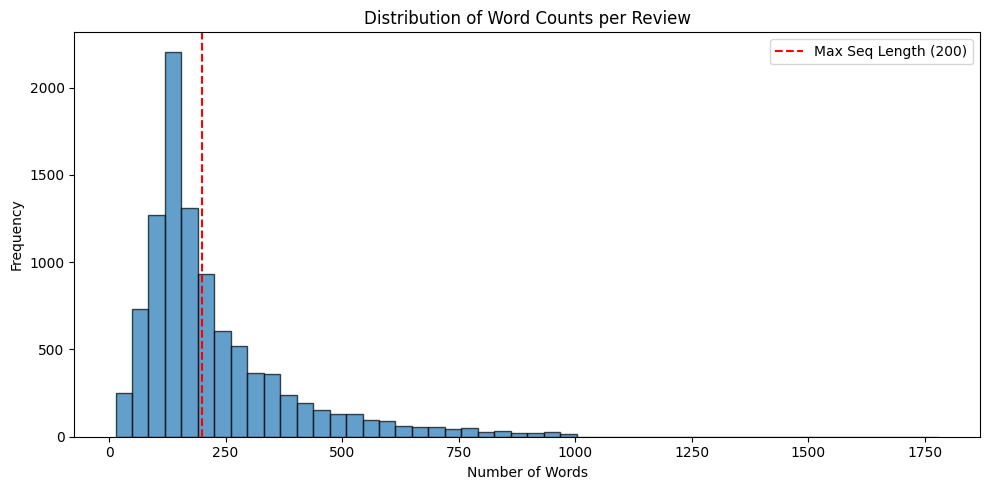

In [ ]:
# ============ VISUALIZATION 1: Histogram of Word Counts ============
df['word_count'] = df['review_split'].apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts per Review')
plt.axvline(x=max_seq_len, color='red', linestyle='--', label=f'Max Seq Length ({max_seq_len})')
plt.legend()
plt.tight_layout()
plt.show()

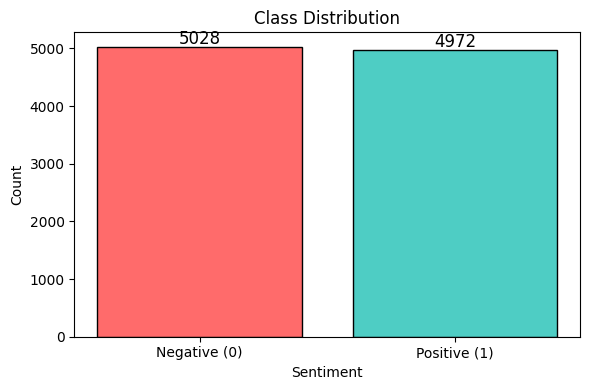

In [ ]:
# ============ VISUALIZATION 2: Class Balance ============
plt.figure(figsize=(6, 4))
sentiment_counts = df['sentiment'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
bars = plt.bar(['Negative (0)', 'Positive (1)'], sentiment_counts.values, color=colors, edgecolor='black')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Class Distribution')
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

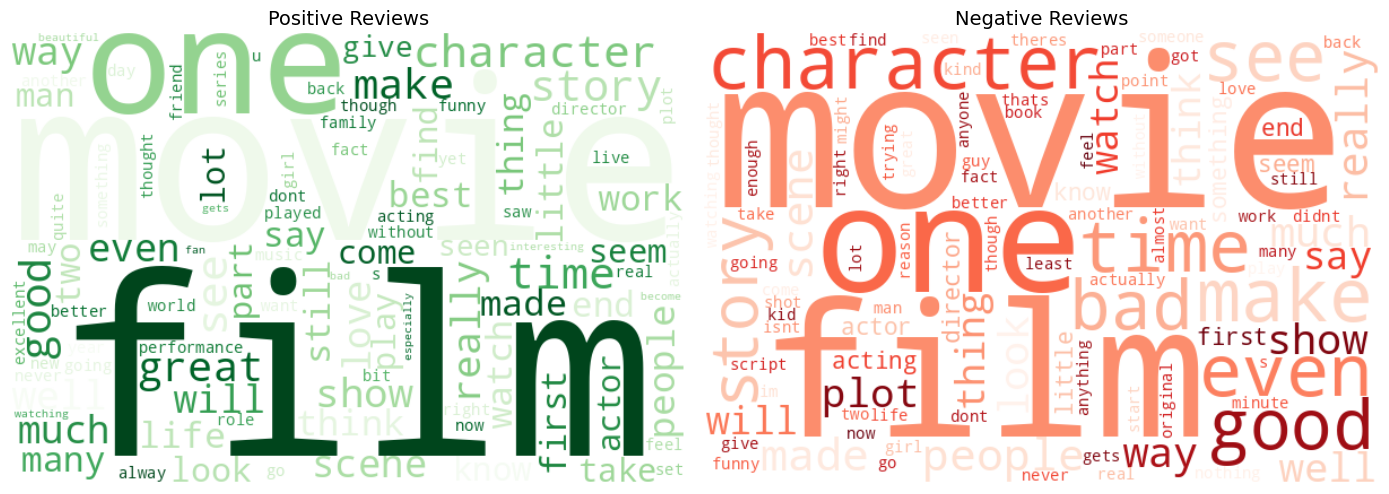

In [ ]:
# ============ VISUALIZATION 3: Word Clouds ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

positive_words = ' '.join(df[df['sentiment'] == 1]['cleaned_review'])
wc_pos = WordCloud(width=600, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=14)
axes[0].axis('off')

negative_words = ' '.join(df[df['sentiment'] == 0]['cleaned_review'])
wc_neg = WordCloud(width=600, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, data):
        self.texts = list(data['encoded_review'])
        self.labels = list(data['sentiment'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.texts[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

train_loader = DataLoader(SentimentDataset(train_data), batch_size=32, shuffle=True)
test_loader  = DataLoader(SentimentDataset(test_data),  batch_size=32, shuffle=False)

In [ ]:
for x, y in train_loader:
    print(x.shape, y.shape)
    break

torch.Size([32, 200]) torch.Size([32])


## Original Models (Baseline — for comparison)

In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, dropout=0.5):
        super(SentimentRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        h0 = torch.zeros(self.rnn.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(embedded, h0)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, patience=5):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"Starting Training...")
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(100 * train_correct / train_total)
        history['val_acc'].append(100 * val_correct / val_total)

        duration = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}% | {duration:.1f}s")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}!")
                break

    return history

In [ ]:
model_orig_rnn = SentimentRNN(vocab_size, embed_size=128, hidden_size=128, output_size=2, dropout=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_orig_rnn.parameters(), lr=0.0005, weight_decay=1e-4)
rnn_history_orig = train_model(model_orig_rnn, train_loader, test_loader)

Starting Training...
Epoch 1/15 | Train Loss: 0.7033 | Val Loss: 0.6986 | Train Acc: 50.51% | Val Acc: 50.20% | 73.6s
Epoch 2/15 | Train Loss: 0.6947 | Val Loss: 0.6975 | Train Acc: 51.34% | Val Acc: 50.15% | 73.8s
Epoch 3/15 | Train Loss: 0.6953 | Val Loss: 0.6970 | Train Acc: 51.24% | Val Acc: 51.00% | 74.5s
Epoch 4/15 | Train Loss: 0.6914 | Val Loss: 0.6991 | Train Acc: 51.98% | Val Acc: 49.50% | 73.5s
Epoch 5/15 | Train Loss: 0.6906 | Val Loss: 0.6980 | Train Acc: 52.38% | Val Acc: 50.40% | 73.8s
Epoch 6/15 | Train Loss: 0.6868 | Val Loss: 0.7068 | Train Acc: 53.51% | Val Acc: 48.60% | 73.4s
Epoch 7/15 | Train Loss: 0.6820 | Val Loss: 0.7036 | Train Acc: 53.36% | Val Acc: 48.30% | 73.7s
Epoch 8/15 | Train Loss: 0.6801 | Val Loss: 0.7109 | Train Acc: 53.69% | Val Acc: 49.80% | 73.7s

Early stopping at epoch 8!


In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SentimentLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, verbose=False):
        embedded = self.embedding(x)
        out, (hn, cn) = self.lstm(embedded)
        last_step = self.dropout(out[:, -1, :])
        return self.fc(last_step)

model_orig_lstm = SentimentLSTM(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_orig_lstm.parameters(), lr=0.001)
lstm_history_orig = train_model(model_orig_lstm, train_loader, test_loader, epochs=15)

Starting Training...
Epoch 1/15 | Train Loss: 0.6936 | Val Loss: 0.6942 | Train Acc: 52.02% | Val Acc: 50.30% | 67.8s
Epoch 2/15 | Train Loss: 0.6800 | Val Loss: 0.6957 | Train Acc: 55.26% | Val Acc: 53.40% | 67.4s
Epoch 3/15 | Train Loss: 0.6313 | Val Loss: 0.7234 | Train Acc: 59.99% | Val Acc: 52.75% | 67.0s
Epoch 4/15 | Train Loss: 0.5553 | Val Loss: 0.7958 | Train Acc: 65.70% | Val Acc: 54.95% | 66.7s
Epoch 5/15 | Train Loss: 0.4734 | Val Loss: 0.8713 | Train Acc: 69.42% | Val Acc: 53.55% | 67.0s
Epoch 6/15 | Train Loss: 0.4167 | Val Loss: 0.8039 | Train Acc: 79.22% | Val Acc: 61.15% | 66.3s

Early stopping at epoch 6!


In [ ]:
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SentimentGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, verbose=False):
        embedded = self.embedding(x)
        out, hn = self.gru(embedded)
        last_step = self.dropout(out[:, -1, :])
        return self.fc(last_step)

model_orig_gru = SentimentGRU(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_orig_gru.parameters(), lr=0.001)
gru_history_orig = train_model(model_orig_gru, train_loader, test_loader, epochs=15)

Starting Training...
Epoch 1/15 | Train Loss: 0.7010 | Val Loss: 0.7119 | Train Acc: 50.91% | Val Acc: 49.95% | 138.6s
Epoch 2/15 | Train Loss: 0.6913 | Val Loss: 0.6899 | Train Acc: 52.94% | Val Acc: 52.90% | 138.3s
Epoch 3/15 | Train Loss: 0.6141 | Val Loss: 0.5946 | Train Acc: 67.22% | Val Acc: 69.35% | 137.4s
Epoch 4/15 | Train Loss: 0.4160 | Val Loss: 0.5353 | Train Acc: 82.55% | Val Acc: 75.90% | 137.2s
Epoch 5/15 | Train Loss: 0.2270 | Val Loss: 0.5996 | Train Acc: 91.16% | Val Acc: 78.30% | 138.7s
Epoch 6/15 | Train Loss: 0.0983 | Val Loss: 0.7062 | Train Acc: 96.83% | Val Acc: 77.80% | 138.0s
Epoch 7/15 | Train Loss: 0.0536 | Val Loss: 0.7944 | Train Acc: 98.30% | Val Acc: 79.20% | 137.3s
Epoch 8/15 | Train Loss: 0.0269 | Val Loss: 0.9339 | Train Acc: 99.29% | Val Acc: 77.80% | 135.0s
Epoch 9/15 | Train Loss: 0.0184 | Val Loss: 1.0634 | Train Acc: 99.53% | Val Acc: 77.90% | 136.1s

Early stopping at epoch 9!


## Phase 1 — Fixed Architectures

### Problems Identified
- **RNN**: Flat validation loss → underfitting. Learning rate too low, model too small.
- **LSTM / GRU**: Validation loss explodes after epoch 4–5 → overfitting. Not enough regularisation.

### Fixes Applied
| Fix | RNN | LSTM | GRU |
|-----|-----|------|-----|
| Increased hidden size | 128 → 256 | — | — |
| Reduced hidden size | — | 128 → 64 | 128 → 64 |
| Higher learning rate | 0.0005 → 0.001 | — | — |
| Dropout (embedding) | ✓ | ✓ (0.4) | ✓ (0.4) |
| Dropout (before FC) | ✓ | ✓ (0.4) | ✓ (0.4) |
| Gradient clipping | ✓ | ✓ | ✓ |
| LR Scheduler (ReduceLROnPlateau) | ✓ | ✓ | ✓ |
| Early stopping | ✓ | ✓ | ✓ |

In [ ]:
def train_model_improved(model, train_loader, val_loader, optimizer, criterion,
                          epochs=20, patience=5, clip_grad=1.0, scheduler=None):
    """
    Improved training loop with:
      - Gradient clipping (clip_grad_norm_)
      - LR scheduler support
      - Early stopping with best-model checkpoint
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    print("Starting Improved Training...")
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()

            # ── Gradient Clipping ──────────────────────────────────────────
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # ── Validation ────────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(100 * train_correct / train_total)
        history['val_acc'].append(100 * val_correct / val_total)

        # ── LR Scheduler step ─────────────────────────────────────────────
        if scheduler is not None:
            scheduler.step(avg_val_loss)
            current_lr = optimizer.param_groups[0]['lr']
        else:
            current_lr = optimizer.param_groups[0]['lr']

        duration = time.time() - start_time
        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}% | "
              f"LR: {current_lr:.6f} | {duration:.1f}s")

        # ── Early Stopping ────────────────────────────────────────────────
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            import copy
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}! "
                      f"Val loss hasn't improved for {patience} epochs.")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model weights (val_loss={best_val_loss:.4f})")

    return history

In [ ]:
# ============================================================
# FIXED RNN
# Fix: higher capacity (hidden 256), dropout at embedding + FC,
#      higher lr, grad clip, LR scheduler
# ============================================================
class FixedRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256, output_size=2, dropout=0.4):
        super(FixedRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding   = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.emb_drop    = nn.Dropout(dropout)            # dropout after embedding
        self.rnn         = nn.RNN(embed_size, hidden_size, num_layers=2,
                                  batch_first=True, dropout=0.3, nonlinearity='relu')
        self.fc_drop     = nn.Dropout(dropout)            # dropout before FC
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.emb_drop(self.embedding(x))
        h0 = torch.zeros(2, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(embedded, h0)
        out = self.fc_drop(out[:, -1, :])
        return self.fc(out)

criterion     = nn.CrossEntropyLoss()
model_rnn_fix = FixedRNN(vocab_size).to(device)
opt_rnn       = optim.Adam(model_rnn_fix.parameters(), lr=0.001, weight_decay=1e-4)
sched_rnn     = optim.lr_scheduler.ReduceLROnPlateau(opt_rnn, mode='min', factor=0.5,
                                                      patience=2)

print("=== Fixed RNN ===")
rnn_history_fix = train_model_improved(model_rnn_fix, train_loader, test_loader,
                                        opt_rnn, criterion, epochs=20, patience=5,
                                        clip_grad=1.0, scheduler=sched_rnn)

=== Fixed RNN ===
Starting Improved Training...
Epoch  1/20 | Train Loss: 0.6963 | Val Loss: 0.6958 | Train Acc: 49.94% | Val Acc: 47.80% | LR: 0.001000 | 102.7s
Epoch  2/20 | Train Loss: 0.6922 | Val Loss: 0.6945 | Train Acc: 51.11% | Val Acc: 49.60% | LR: 0.001000 | 102.4s
Epoch  3/20 | Train Loss: 0.6910 | Val Loss: 0.6948 | Train Acc: 52.99% | Val Acc: 48.65% | LR: 0.001000 | 99.3s
Epoch  4/20 | Train Loss: 0.6880 | Val Loss: 0.6979 | Train Acc: 53.89% | Val Acc: 48.60% | LR: 0.001000 | 99.9s
Epoch  5/20 | Train Loss: 0.6844 | Val Loss: 0.7003 | Train Acc: 54.55% | Val Acc: 48.70% | LR: 0.000500 | 100.1s
Epoch  6/20 | Train Loss: 0.6730 | Val Loss: 0.7054 | Train Acc: 56.38% | Val Acc: 48.70% | LR: 0.000500 | 99.0s
Epoch  7/20 | Train Loss: 0.6624 | Val Loss: 0.7143 | Train Acc: 57.23% | Val Acc: 49.45% | LR: 0.000500 | 98.7s

Early stopping at epoch 7! Val loss hasn't improved for 5 epochs.
Restored best model weights (val_loss=0.6945)


In [ ]:
# ============================================================
# FIXED LSTM
# Fix: smaller hidden (64), heavier dropout (0.4 at embedding + FC),
#      grad clip, LR scheduler
# ============================================================
class FixedLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=64, output_size=2, dropout=0.4):
        super(FixedLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.emb_drop  = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(embed_size, hidden_size, num_layers=2,
                                  batch_first=True, dropout=0.3)
        self.fc_drop   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.emb_drop(self.embedding(x))
        out, _   = self.lstm(embedded)
        out      = self.fc_drop(out[:, -1, :])
        return self.fc(out)

model_lstm_fix = FixedLSTM(vocab_size).to(device)
opt_lstm       = optim.Adam(model_lstm_fix.parameters(), lr=0.001, weight_decay=1e-4)
sched_lstm     = optim.lr_scheduler.ReduceLROnPlateau(opt_lstm, mode='min', factor=0.5,
                                                        patience=2)

print("=== Fixed LSTM ===")
lstm_history_fix = train_model_improved(model_lstm_fix, train_loader, test_loader,
                                         opt_lstm, criterion, epochs=20, patience=5,
                                         clip_grad=1.0, scheduler=sched_lstm)

=== Fixed LSTM ===
Starting Improved Training...
Epoch  1/20 | Train Loss: 0.6937 | Val Loss: 0.6934 | Train Acc: 50.23% | Val Acc: 49.75% | LR: 0.001000 | 52.3s
Epoch  2/20 | Train Loss: 0.6892 | Val Loss: 0.6959 | Train Acc: 53.38% | Val Acc: 50.40% | LR: 0.001000 | 52.8s
Epoch  3/20 | Train Loss: 0.6875 | Val Loss: 0.6947 | Train Acc: 53.39% | Val Acc: 51.75% | LR: 0.001000 | 52.3s
Epoch  4/20 | Train Loss: 0.6819 | Val Loss: 0.6907 | Train Acc: 54.42% | Val Acc: 51.70% | LR: 0.001000 | 52.1s
Epoch  5/20 | Train Loss: 0.6753 | Val Loss: 0.6865 | Train Acc: 55.94% | Val Acc: 52.65% | LR: 0.001000 | 52.7s
Epoch  6/20 | Train Loss: 0.6649 | Val Loss: 0.6332 | Train Acc: 60.10% | Val Acc: 66.70% | LR: 0.001000 | 52.8s
Epoch  7/20 | Train Loss: 0.6261 | Val Loss: 0.6236 | Train Acc: 66.65% | Val Acc: 68.55% | LR: 0.001000 | 52.4s
Epoch  8/20 | Train Loss: 0.5995 | Val Loss: 0.6098 | Train Acc: 69.78% | Val Acc: 70.00% | LR: 0.001000 | 52.7s
Epoch  9/20 | Train Loss: 0.5577 | Val Loss: 0.

In [ ]:
# ============================================================
# FIXED GRU
# Fix: same strategy as LSTM — reduced capacity + more dropout
# ============================================================
class FixedGRU(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=64, output_size=2, dropout=0.4):
        super(FixedGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.emb_drop  = nn.Dropout(dropout)
        self.gru       = nn.GRU(embed_size, hidden_size, num_layers=2,
                                 batch_first=True, dropout=0.3)
        self.fc_drop   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.emb_drop(self.embedding(x))
        out, _   = self.gru(embedded)
        out      = self.fc_drop(out[:, -1, :])
        return self.fc(out)

model_gru_fix = FixedGRU(vocab_size).to(device)
opt_gru       = optim.Adam(model_gru_fix.parameters(), lr=0.001, weight_decay=1e-4)
sched_gru     = optim.lr_scheduler.ReduceLROnPlateau(opt_gru, mode='min', factor=0.5,
                                                       patience=2)

print("=== Fixed GRU ===")
gru_history_fix = train_model_improved(model_gru_fix, train_loader, test_loader,
                                        opt_gru, criterion, epochs=20, patience=5,
                                        clip_grad=1.0, scheduler=sched_gru)

=== Fixed GRU ===
Starting Improved Training...
Epoch  1/20 | Train Loss: 0.6951 | Val Loss: 0.6952 | Train Acc: 49.96% | Val Acc: 50.35% | LR: 0.001000 | 113.8s
Epoch  2/20 | Train Loss: 0.6911 | Val Loss: 0.6936 | Train Acc: 51.77% | Val Acc: 50.55% | LR: 0.001000 | 113.2s
Epoch  3/20 | Train Loss: 0.6868 | Val Loss: 0.6923 | Train Acc: 52.95% | Val Acc: 51.20% | LR: 0.001000 | 114.0s
Epoch  4/20 | Train Loss: 0.6821 | Val Loss: 0.6929 | Train Acc: 54.44% | Val Acc: 51.50% | LR: 0.001000 | 114.9s
Epoch  5/20 | Train Loss: 0.6728 | Val Loss: 0.6895 | Train Acc: 55.39% | Val Acc: 53.20% | LR: 0.001000 | 114.9s
Epoch  6/20 | Train Loss: 0.6589 | Val Loss: 0.6514 | Train Acc: 59.88% | Val Acc: 64.30% | LR: 0.001000 | 114.5s
Epoch  7/20 | Train Loss: 0.6216 | Val Loss: 0.6581 | Train Acc: 66.17% | Val Acc: 65.45% | LR: 0.001000 | 115.1s
Epoch  8/20 | Train Loss: 0.5590 | Val Loss: 0.5937 | Train Acc: 73.60% | Val Acc: 73.20% | LR: 0.001000 | 114.6s
Epoch  9/20 | Train Loss: 0.4998 | Val L

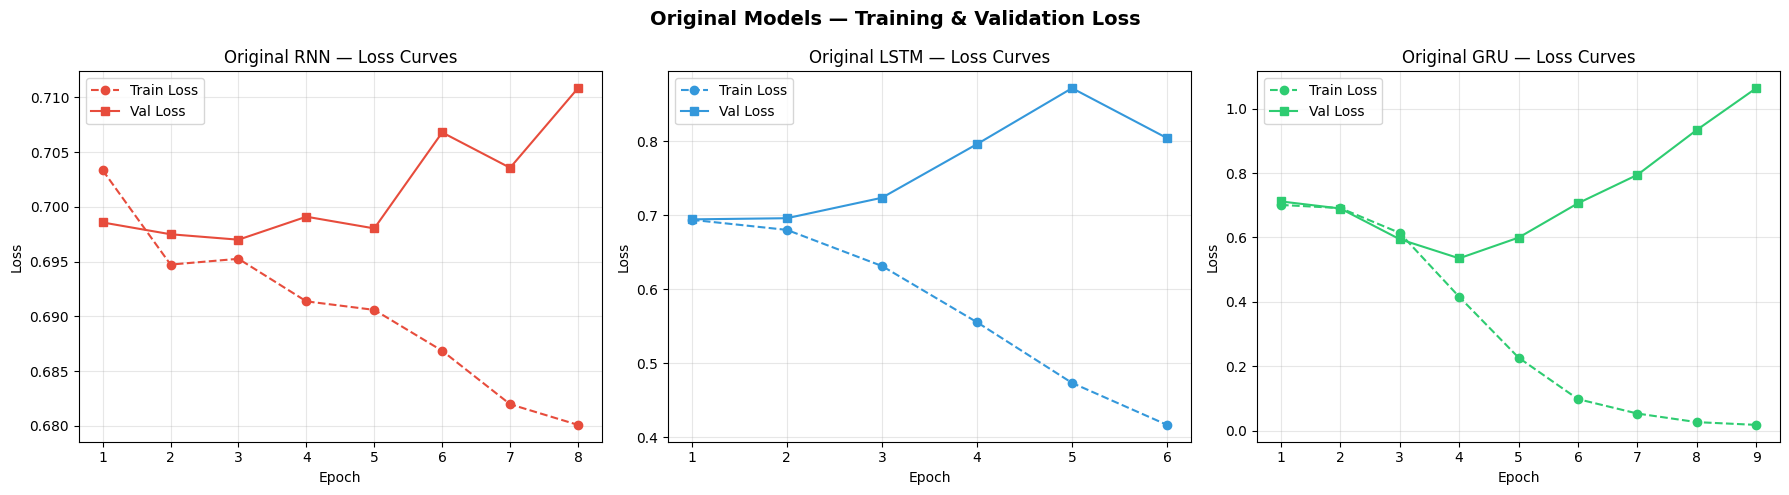

In [ ]:
# ============================================================
# Original per-model loss curves (RNN, LSTM, GRU — original)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, hist, name, color in zip(
        axes,
        [rnn_history_orig, lstm_history_orig, gru_history_orig],
        ['RNN', 'LSTM', 'GRU'],
        ['#e74c3c', '#3498db', '#2ecc71']):
    ep = range(1, len(hist['train_loss']) + 1)
    ax.plot(ep, hist['train_loss'], label='Train Loss', color=color, marker='o', linestyle='--')
    ax.plot(ep, hist['val_loss'],   label='Val Loss',   color=color, marker='s')
    ax.set_title(f'Original {name} — Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Original Models — Training & Validation Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

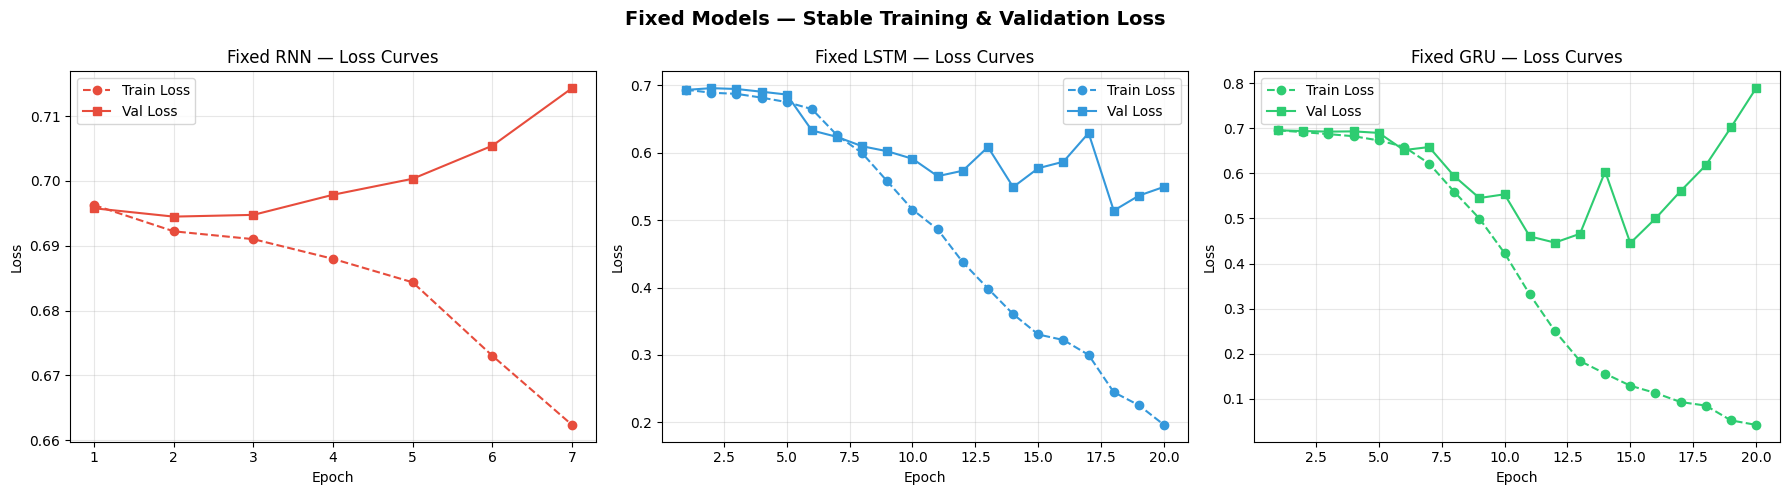

In [ ]:
# ============================================================
# Fixed per-model loss curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, hist, name, color in zip(
        axes,
        [rnn_history_fix, lstm_history_fix, gru_history_fix],
        ['RNN', 'LSTM', 'GRU'],
        ['#e74c3c', '#3498db', '#2ecc71']):
    ep = range(1, len(hist['train_loss']) + 1)
    ax.plot(ep, hist['train_loss'], label='Train Loss', color=color, marker='o', linestyle='--')
    ax.plot(ep, hist['val_loss'],   label='Val Loss',   color=color, marker='s')
    ax.set_title(f'Fixed {name} — Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Fixed Models — Stable Training & Validation Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

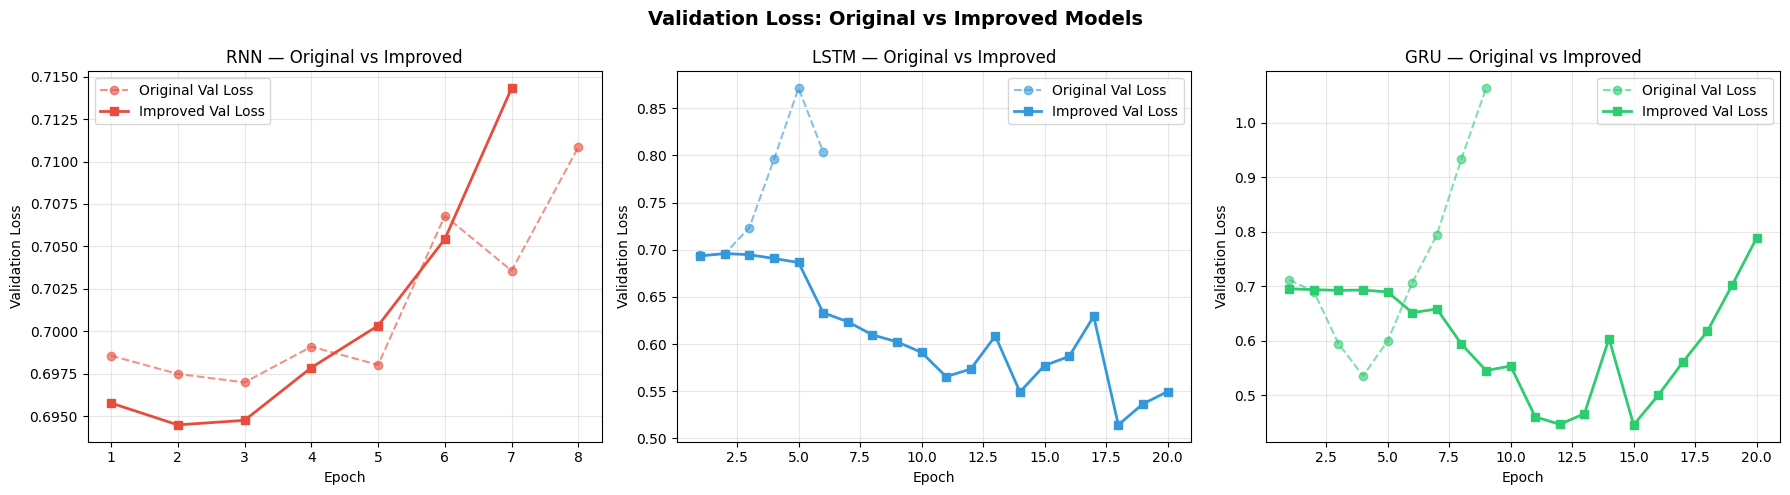

Saved: phase1_comparison_loss.png


In [ ]:
# ============================================================
# COMPARISON PLOT: Original vs Improved Validation Loss
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    (rnn_history_orig,  rnn_history_fix,  'RNN',  '#e74c3c'),
    (lstm_history_orig, lstm_history_fix, 'LSTM', '#3498db'),
    (gru_history_orig,  gru_history_fix,  'GRU',  '#2ecc71'),
]

for ax, (orig, fixed, name, color) in zip(axes, pairs):
    ep_o = range(1, len(orig['val_loss'])  + 1)
    ep_f = range(1, len(fixed['val_loss']) + 1)
    ax.plot(ep_o, orig['val_loss'],  label='Original Val Loss', color=color,
            linestyle='--', marker='o', alpha=0.6)
    ax.plot(ep_f, fixed['val_loss'], label='Improved Val Loss', color=color,
            linestyle='-',  marker='s', linewidth=2)
    ax.set_title(f'{name} — Original vs Improved', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Validation Loss: Original vs Improved Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phase1_comparison_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase1_comparison_loss.png")

In [ ]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

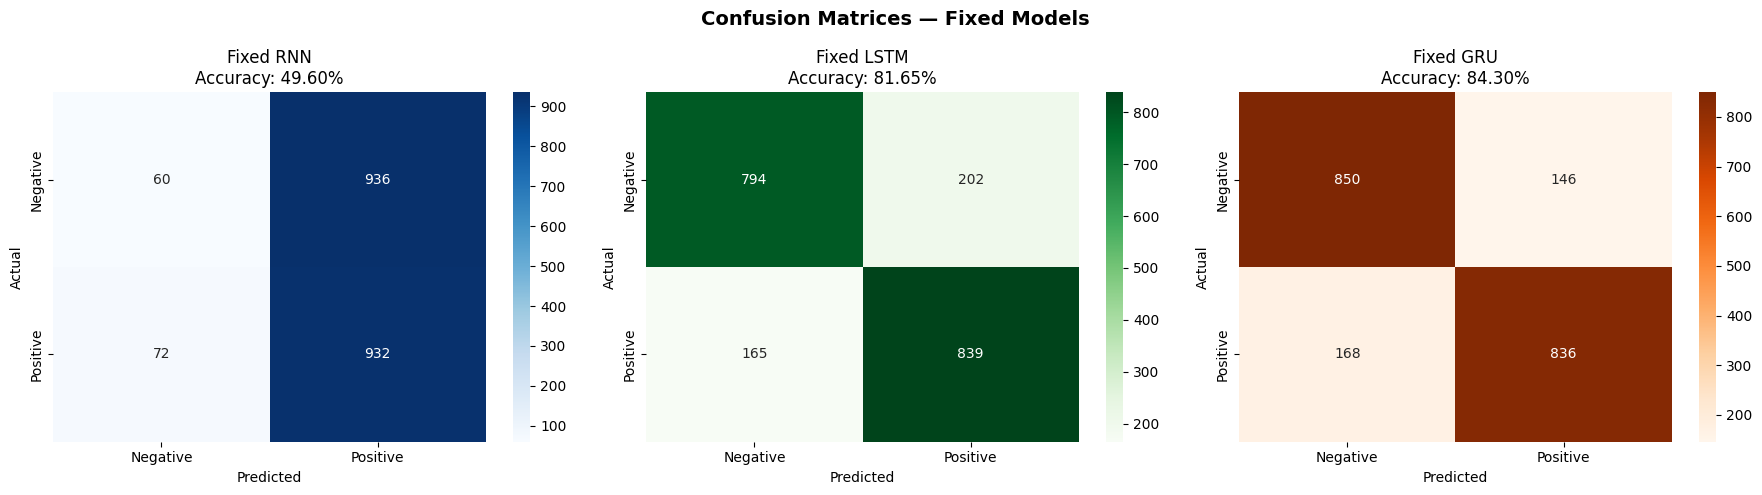

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps  = ['Blues', 'Greens', 'Oranges']
models_fixed = [model_rnn_fix, model_lstm_fix, model_gru_fix]
names  = ['Fixed RNN', 'Fixed LSTM', 'Fixed GRU']

for ax, model, name, cmap in zip(axes, models_fixed, names, cmaps):
    y_true, y_pred = get_predictions(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)
    acc = 100 * np.trace(cm) / np.sum(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name}\nAccuracy: {acc:.2f}%')

plt.suptitle('Confusion Matrices — Fixed Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 2 — Ensemble System

Three voting strategies are implemented:
1. **Hard Voting** — majority class wins across the three models
2. **Soft Voting** — average of softmax probability vectors; pick highest
3. **Weighted Voting** — weight each model's softmax by its validation accuracy

In [ ]:
def get_probs_and_labels(model, loader):
    """Returns (N,2) softmax probability matrix and (N,) ground-truth labels."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            logits = model(texts)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)

# Collect probs from all three fixed models
probs_rnn,  y_true = get_probs_and_labels(model_rnn_fix,  test_loader)
probs_lstm, _      = get_probs_and_labels(model_lstm_fix, test_loader)
probs_gru,  _      = get_probs_and_labels(model_gru_fix,  test_loader)

# Hard predictions
preds_rnn  = np.argmax(probs_rnn,  axis=1)
preds_lstm = np.argmax(probs_lstm, axis=1)
preds_gru  = np.argmax(probs_gru,  axis=1)

print("Probs shape:", probs_rnn.shape, "| Labels shape:", y_true.shape)

Probs shape: (2000, 2) | Labels shape: (2000,)


In [ ]:
# ── Validation accuracies (used for weighted voting) ──────────────────────
acc_rnn  = rnn_history_fix['val_acc'][-1]  / 100
acc_lstm = lstm_history_fix['val_acc'][-1] / 100
acc_gru  = gru_history_fix['val_acc'][-1]  / 100

print(f"Val Acc → RNN: {acc_rnn:.4f} | LSTM: {acc_lstm:.4f} | GRU: {acc_gru:.4f}")

# ── 1. Hard Voting ────────────────────────────────────────────────────────
votes     = np.stack([preds_rnn, preds_lstm, preds_gru], axis=1)  # (N,3)
hard_preds = np.apply_along_axis(
    lambda row: np.bincount(row, minlength=2).argmax(), axis=1, arr=votes)

# ── 2. Soft Voting ────────────────────────────────────────────────────────
avg_probs  = (probs_rnn + probs_lstm + probs_gru) / 3
soft_preds = np.argmax(avg_probs, axis=1)

# ── 3. Weighted Voting ────────────────────────────────────────────────────
total_weight  = acc_rnn + acc_lstm + acc_gru
w_rnn  = acc_rnn  / total_weight
w_lstm = acc_lstm / total_weight
w_gru  = acc_gru  / total_weight

weighted_probs  = w_rnn * probs_rnn + w_lstm * probs_lstm + w_gru * probs_gru
weighted_preds  = np.argmax(weighted_probs, axis=1)

print(f"\nWeights → RNN: {w_rnn:.4f} | LSTM: {w_lstm:.4f} | GRU: {w_gru:.4f}")

Val Acc → RNN: 0.4945 | LSTM: 0.8125 | GRU: 0.8480

Weights → RNN: 0.2295 | LSTM: 0.3770 | GRU: 0.3935


In [ ]:
# ============================================================
# ACCURACY TABLE — Individual + Ensemble
# ============================================================
def accuracy(y_true, y_pred):
    return 100 * np.mean(y_true == y_pred)

results = {
    'Model':    ['Original RNN', 'Original LSTM', 'Original GRU',
                 'Fixed RNN',    'Fixed LSTM',    'Fixed GRU',
                 'Hard Voting',  'Soft Voting',   'Weighted Voting'],
    'Accuracy': [
        rnn_history_orig['val_acc'][-1],
        lstm_history_orig['val_acc'][-1],
        gru_history_orig['val_acc'][-1],
        accuracy(y_true, preds_rnn),
        accuracy(y_true, preds_lstm),
        accuracy(y_true, preds_gru),
        accuracy(y_true, hard_preds),
        accuracy(y_true, soft_preds),
        accuracy(y_true, weighted_preds),
    ]
}

results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].round(2)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("\n" + "="*45)
print("       ACCURACY TABLE")
print("="*45)
print(results_df.to_string(index=False))
print("="*45)


       ACCURACY TABLE
          Model  Accuracy
Weighted Voting     84.30
      Fixed GRU     84.30
    Soft Voting     84.25
    Hard Voting     83.10
     Fixed LSTM     81.65
   Original GRU     77.90
  Original LSTM     61.15
   Original RNN     49.80
      Fixed RNN     49.60


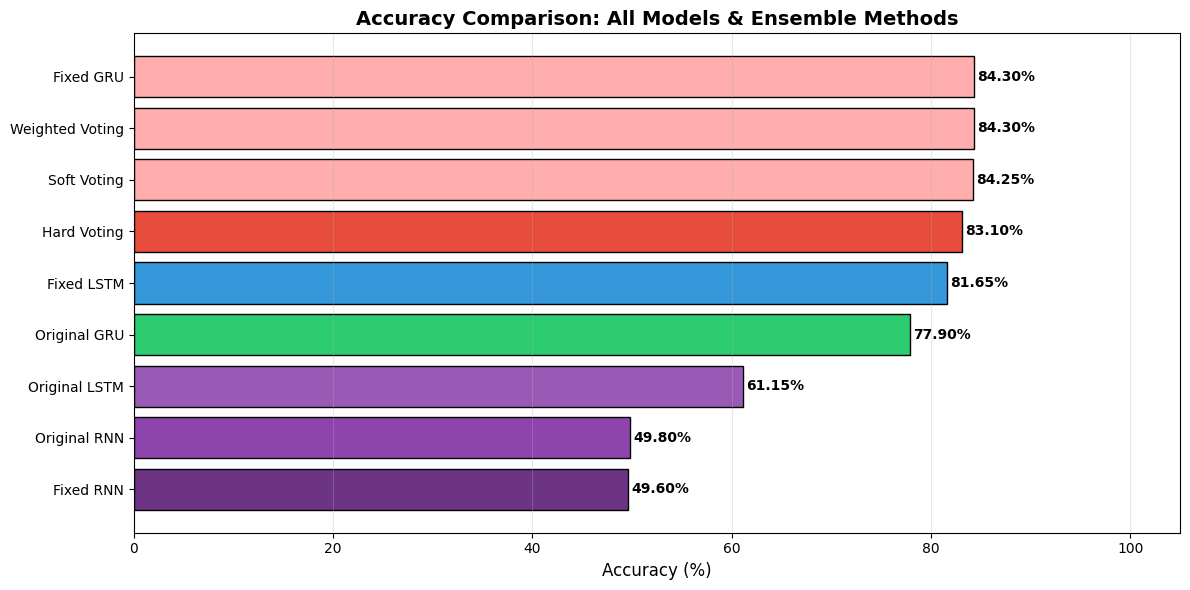

Saved: accuracy_table_chart.png


In [ ]:
# ── Bar Chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors_list = (['#ffadad']*3 +          # originals – light
               ['#e74c3c', '#3498db', '#2ecc71'] +  # fixed individual
               ['#9b59b6', '#8e44ad', '#6c3483'])    # ensemble

sorted_df = results_df.sort_values('Accuracy')
bars = ax.barh(sorted_df['Model'], sorted_df['Accuracy'], color=colors_list[::-1][:len(sorted_df)],
               edgecolor='black')

for bar, acc in zip(bars, sorted_df['Accuracy']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Comparison: All Models & Ensemble Methods', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_table_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: accuracy_table_chart.png")

In [ ]:
def predict_all(text, model_rnn, model_lstm, model_gru, word_to_idx, max_len=200):
    """Returns per-model predictions + all three ensemble predictions."""
    tokens  = re.sub(r'[^a-zA-Z\s]', '', text.lower()).split()
    encoded = [min(word_to_idx.get(w, 0), vocab_size - 1) for w in tokens]
    encoded = encoded[:max_len] + [0] * (max_len - len(encoded))
    tensor  = torch.tensor([encoded], dtype=torch.long).to(device)

    def _probs(m):
        m.eval()
        with torch.no_grad():
            return torch.softmax(m(tensor), dim=1).cpu().numpy()[0]

    p_rnn  = _probs(model_rnn)
    p_lstm = _probs(model_lstm)
    p_gru  = _probs(model_gru)

    label = lambda p: ("Positive" if np.argmax(p) == 1 else "Negative",
                        p[np.argmax(p)] * 100)

    # Hard vote
    votes_arr = [np.argmax(p_rnn), np.argmax(p_lstm), np.argmax(p_gru)]
    hard_vote  = "Positive" if sum(votes_arr) >= 2 else "Negative"

    # Soft vote
    soft_avg  = (p_rnn + p_lstm + p_gru) / 3
    soft_vote  = "Positive" if np.argmax(soft_avg) == 1 else "Negative"
    soft_conf  = soft_avg[np.argmax(soft_avg)] * 100

    # Weighted vote
    w_arr = np.array([acc_rnn, acc_lstm, acc_gru])
    w_arr = w_arr / w_arr.sum()
    w_avg = w_arr[0]*p_rnn + w_arr[1]*p_lstm + w_arr[2]*p_gru
    wt_vote = "Positive" if np.argmax(w_avg) == 1 else "Negative"
    wt_conf  = w_avg[np.argmax(w_avg)] * 100

    return {
        'rnn':      label(p_rnn),
        'lstm':     label(p_lstm),
        'gru':      label(p_gru),
        'hard':     (hard_vote, None),
        'soft':     (soft_vote, soft_conf),
        'weighted': (wt_vote,  wt_conf),
    }

In [ ]:
# ============================================================
# 5 Examples where individual models DISAGREED but ensemble
# corrected the mistake
# ============================================================

# Scan test set for disagreements where at least one model was wrong
#  and the ensemble (soft voting) was correct.
test_texts_raw  = list(test_data['cleaned_review'])
test_labels_raw = list(test_data['sentiment'])

print("Scanning test set for disagreement examples...\n")

disagreements = []
for i, (text, true_label) in enumerate(zip(test_texts_raw, test_labels_raw)):
    if len(disagreements) >= 5:
        break

    r = preds_rnn[i]
    l = preds_lstm[i]
    g = preds_gru[i]
    s = soft_preds[i]

    # At least two models disagree (not unanimous)
    if not (r == l == g):
        # At least one individual model is WRONG
        if not (r == true_label and l == true_label and g == true_label):
            # Ensemble (soft) is CORRECT
            if s == true_label:
                disagreements.append({
                    'text': text[:120] + '...' if len(text) > 120 else text,
                    'true': 'Positive' if true_label == 1 else 'Negative',
                    'rnn':  'Positive' if r == 1 else 'Negative',
                    'lstm': 'Positive' if l == 1 else 'Negative',
                    'gru':  'Positive' if g == 1 else 'Negative',
                    'soft': 'Positive' if s == 1 else 'Negative',
                })

print(f"Found {len(disagreements)} disagreement examples where ensemble corrected mistakes:\n")
print("=" * 90)
for idx, ex in enumerate(disagreements, 1):
    print(f"Example {idx}:")
    print(f"  Review   : {ex['text']}")
    print(f"  True Label  : {ex['true']}")
    print(f"  RNN Pred    : {ex['rnn']}  {'✓' if ex['rnn']==ex['true'] else '✗'}")
    print(f"  LSTM Pred   : {ex['lstm']} {'✓' if ex['lstm']==ex['true'] else '✗'}")
    print(f"  GRU Pred    : {ex['gru']}  {'✓' if ex['gru']==ex['true'] else '✗'}")
    print(f"  Soft Ensemble: {ex['soft']} {'✓' if ex['soft']==ex['true'] else '✗'}")
    print("-" * 90)

Scanning test set for disagreement examples...

Found 5 disagreement examples where ensemble corrected mistakes:

Example 1:
  Review   : this is a pretty pointless remake starting with the opening title shots of the original was a real mistake as it reminds...
  True Label  : Negative
  RNN Pred    : Positive  ✗
  LSTM Pred   : Negative ✓
  GRU Pred    : Negative  ✓
  Soft Ensemble: Negative ✓
------------------------------------------------------------------------------------------
Example 2:
  Review   : i picked up this movie with the intention of getting a bad zombie movie but i had no idea what i was getting myself into...
  True Label  : Negative
  RNN Pred    : Positive  ✗
  LSTM Pred   : Negative ✓
  GRU Pred    : Negative  ✓
  Soft Ensemble: Negative ✓
------------------------------------------------------------------------------------------
Example 3:
  Review   : i have never seen a movie so bad its not even entertaining enough to be a drinking gameits so bad i dont even wa

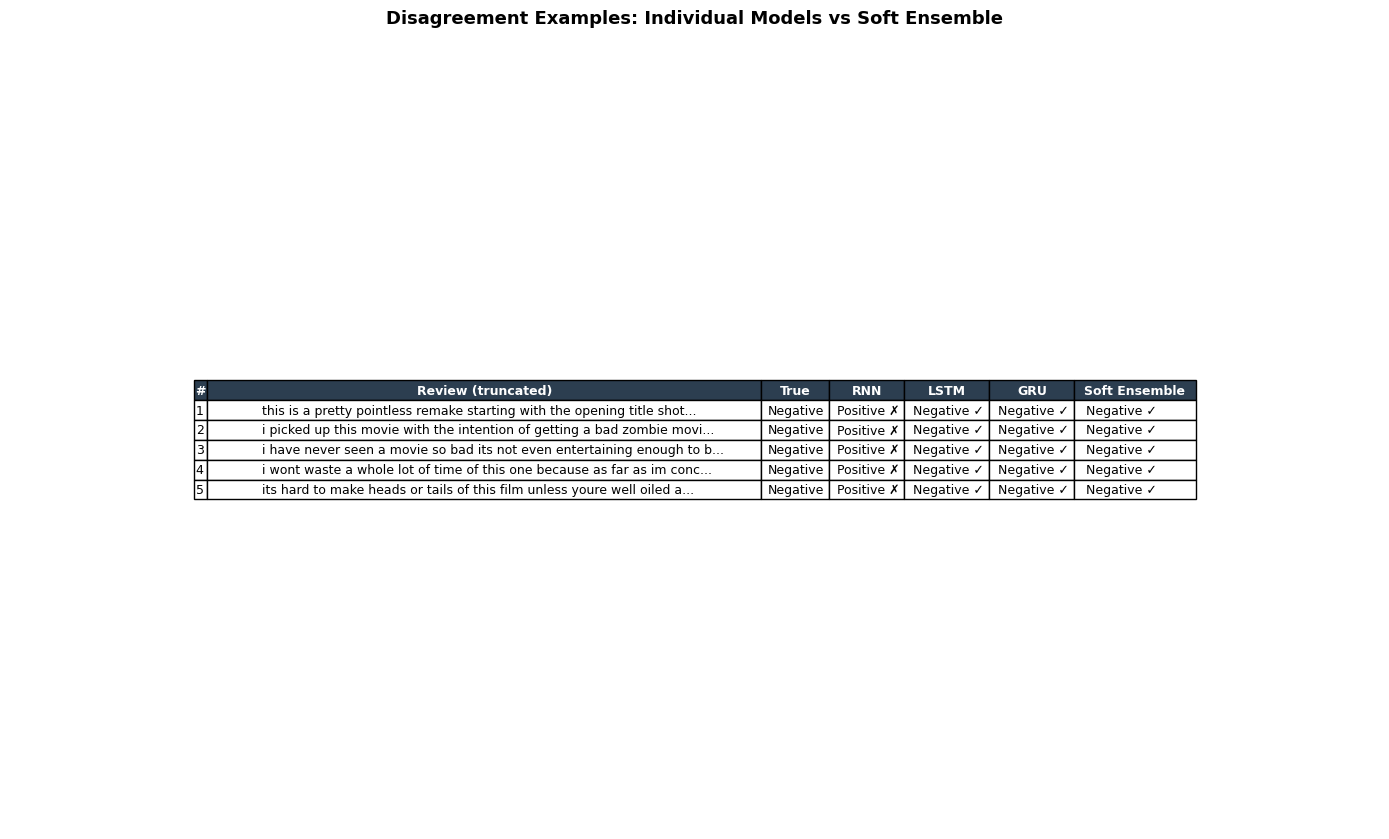

Saved: disagreement_examples.png


In [ ]:
# ── Visual table of disagreement examples ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, len(disagreements) * 1.4 + 1.5))
ax.axis('off')

col_labels = ['#', 'Review (truncated)', 'True', 'RNN', 'LSTM', 'GRU', 'Soft Ensemble']
table_data = []
for i, ex in enumerate(disagreements, 1):
    def mark(pred, true):
        return f"{pred} {'✓' if pred == true else '✗'}"
    table_data.append([
        str(i),
        ex['text'][:70] + '...',
        ex['true'],
        mark(ex['rnn'],  ex['true']),
        mark(ex['lstm'], ex['true']),
        mark(ex['gru'],  ex['true']),
        mark(ex['soft'], ex['true']),
    ])

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(col_labels))))

# Colour header
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

plt.title('Disagreement Examples: Individual Models vs Soft Ensemble',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('disagreement_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: disagreement_examples.png")

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("           PHASE 1 + PHASE 2 SUMMARY")
print("="*60)
print("\nPhase 1 — Fixes Applied:")
print("  RNN  : hidden 128→256, lr 0.0005→0.001, dropout@emb+FC, grad clip, scheduler")
print("  LSTM : hidden 128→64,  dropout 0.3→0.4@emb+FC, grad clip, scheduler")
print("  GRU  : hidden 128→64,  dropout 0.3→0.4@emb+FC, grad clip, scheduler")

print("\nPhase 2 — Ensemble Voting Strategies:")
print(f"  Hard Voting     : {accuracy(y_true, hard_preds):.2f}%")
print(f"  Soft Voting     : {accuracy(y_true, soft_preds):.2f}%")
print(f"  Weighted Voting : {accuracy(y_true, weighted_preds):.2f}%")
print("\nBest individual fixed model:")
indiv = {'RNN': accuracy(y_true, preds_rnn),
         'LSTM': accuracy(y_true, preds_lstm),
         'GRU': accuracy(y_true, preds_gru)}
best_name = max(indiv, key=indiv.get)
print(f"  {best_name}: {indiv[best_name]:.2f}%")
print("="*60)


           PHASE 1 + PHASE 2 SUMMARY

Phase 1 — Fixes Applied:
  RNN  : hidden 128→256, lr 0.0005→0.001, dropout@emb+FC, grad clip, scheduler
  LSTM : hidden 128→64,  dropout 0.3→0.4@emb+FC, grad clip, scheduler
  GRU  : hidden 128→64,  dropout 0.3→0.4@emb+FC, grad clip, scheduler

Phase 2 — Ensemble Voting Strategies:
  Hard Voting     : 83.10%
  Soft Voting     : 84.25%
  Weighted Voting : 84.30%

Best individual fixed model:
  GRU: 84.30%
